In [1]:
import torch
import torchvision
from torchvision import transforms
from torchvision.transforms import Compose, Normalize, ToTensor
from ViT_CX.ViT_CX import ViT_CX
import utils.utils

import numpy as np
import random

from matplotlib import pyplot as plt
import cv2

import time
import pandas as pd

import rasterio as rio
import json
import pickle

import gc

#root = '/home/a01328525/'
root = 'E:/Experiments/'

In [2]:
import argparse
import os

import torch
import torch.utils.data

import model.transformer
import model.trainer as trainer
import utils.datasets
import utils.utils
import utils.plots as plots
import utils.counting as counting
import torchvision
import numpy as np
import warnings
from matplotlib import pyplot as plt

import utils.anchors
import cv2

import time
import pandas as pd

from PIL import Image
from PIL import ImageDraw
from PIL import ImageFont
import rasterio as rio
import json

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

folder_maps = root+'Datasets Maps/'
folder_tiles = root+'Datasets Tiles/'
folder_save_results = root+'Counting images paper 2/'
folder_trained_models = root+"Datasets_STED/runs_transformers/"

img_size = 224

#zone_name='Zone108_octubre'
#zone_name='Zone102_part1'
zone_name='Zone108'
#zone_name='Zone3'


In [3]:
import shutil
#shutil.make_archive("/home/a01328525/transformer_object_dectection", 'zip', "/home/a01328525/transformer_object_dectection")

#shutil.make_archive("/home/a01328525/trained_models", 'zip', "/home/a01328525/Datasets_STED/runs_transformers")
#shutil.make_archive("/home/a01328525/trained_model", 'zip', "/home/a01328525/Datasets_STED/runs_transformers/STED_2_nano_cbbox_bgr_diou_BitNet")

#shutil.make_archive("/home/a01328525/results", 'zip', "/home/a01328525/Counting images paper")

#shutil.make_archive("/home/a01328525/masks20_Zone102_part1", 'zip', "/home/a01328525/Datasets_STED/Explainability/masks20_Zone102_part1")
#shutil.make_archive("/home/a01328525/masks20_Zone3", 'zip', "/home/a01328525/Datasets_STED/Explainability/masks20_Zone3")

## Extract features from each detection

In [25]:
with rio.open(folder_maps + zone_name + "_full.tif") as img :
        imgnp = img.read() 
B = imgnp[0,:,:]; 
G = imgnp[1,:,:]
R = imgnp[2,:,:]
Re = imgnp[3,:,:]
NIR = imgnp[4,:,:]

In [26]:
boxes_filtered.shape

torch.Size([5529, 3])

In [27]:
from utils.utils import VI
from skimage.feature import graycomatrix, graycoprops

Veg_Names = ['NDVI', 'PVI1', 'PVI2', 'SAVI', 'TSAVI2',
             'NDGI', 'ARVI', 'NDCI', 'MSAVI', 'NLI',
             'RDVI', 'GNDVI', 'OSAVI', 'MSR',
             'EVI', 'EVI2']
N_boxes = boxes_filtered.shape[0]
data = [] #matrix of features, rows represent each agave and the columns the features
#print('Total of Agaves: '+str(len(data['shapes'])))
#for l in labels:
#imgnp = cv2.imread(folder_maps + zone_name + "_bgr.png")
img = imgnp[4,...] # VI((B, G, R, Re, NIR), 'ARVI')
l=1
eps=1e-8

# Texture parameters
levels = 8
gray_max=1
distance= 1.0
angle = 0

#for index in filtered_indexes:
for i, box in enumerate(boxes_filtered):
#for i in jsonData['shapes']:
    xc, yc, r = box
    mask = np.asarray(masks_filtered[i]).astype('uint8')
    xc = int(xc); yc=int(yc); r = int(r)

    contours, hierarchy = cv2.findContours(mask, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)

    if contours:
        # Find the largest contour by area using the max() function with cv2.contourArea as the key
        cnt = max(contours, key=cv2.contourArea)
#    cnt = np.array(i['points'])
#    cnt = (cnt.reshape((cnt.shape[0], 1, 2))).astype('int32')

    print('\r', "Agave "+str(l) + "/"+str(N_boxes), end='')
    l+=1
    
    ################################## Morphological Features #############################################
    #if len(all_masks[index])>0:
    #cnt = all_masks[index]
    #area = 3.1416*r**2#cv2.contourArea(cnt)               #area
    area = cv2.contourArea(cnt) 
    #if area<70:
    #    continue
    #perimeter = 3.1416*2*r#cv2.arcLength(cnt, True)      #perimeter
    perimeter = cv2.arcLength(cnt, True)
    compactness = perimeter*perimeter/(area+eps)   #compactness
    circularity = 4*np.pi*area/(perimeter**2+eps) #circularity
    effect_diameter = 2*np.sqrt(area/np.pi)   #effective diameter
    # fit contour to ellipse and get ellipse center, minor and major diameters and angle in degree
    #ellipse = cv2.fitEllipse(cnt)
    #(xc,yc),(d1,d2),angle = ellipse           #d1: minor axis, d2:major axis, angle: orientation
    #eccentricity = np.sqrt(1-(d1/d2)**2)      #eccentricity
    hull = cv2.convexHull(cnt)
    hull_area = cv2.contourArea(hull)         #convex area
    # bounding box area
    #x,y,w,h = cv2.boundingRect(cnt)
    #rect_area = w*h
    #extent = area/rect_area                   #extent
    solidity = area/(hull_area+eps)          #solidity
    #if yc>R.shape[0]-1:
    #    yc=R.shape[0]-1
    #if xc>R.shape[1]-1:
    #    xc=R.shape[1]-1

    shape_index = perimeter/(4*np.sqrt(area)+eps)
    #s = [[np.var(cnt[:,0]), np.cov(cnt[:,0], cnt[:,1],bias=True)[0][1]], [np.cov(cnt[:,0], cnt[:,1],bias=True)[0][1], np.var(cnt[:,1])]]
    #eigV, _ = np.linalg.eig(s)
    #idx = eigV.argsort(); eigV = eigV[idx]
    #len_width = eigV[1]/eigV[0]
    #len_2d = np.sqrt(area*len_width)
    
    ################################## Texture Features #############################################
    bins = np.linspace(0, gray_max, levels+1)
    bins = np.digitize(img[int(yc-r):int(yc+r), int(xc-r):int(xc+r)], bins) - 1 #-1 to start in 0
    bins = np.clip(bins, 0, levels-1)
    result = graycomatrix(bins, [distance], [angle], levels=levels, normed = True)
    contrast = graycoprops(result, 'contrast')[0,0]
    dissimilarity = graycoprops(result, 'dissimilarity')[0,0]
    homogeneity = graycoprops(result, 'homogeneity')[0,0]
    ASM = graycoprops(result, 'ASM')[0,0]
    energy = graycoprops(result, 'energy')[0,0]

    d = [int(xc), int(yc), area, perimeter, compactness, circularity, effect_diameter,
         shape_index, hull_area, solidity,
        contrast, dissimilarity, homogeneity, ASM, energy] 
    
    ################################## Spectral Features #############################################
    #labeled = cv2.drawContours(np.zeros_like(R), [cnt], -1, (1), cv2.FILLED)
    labeled = cv2.circle(np.zeros_like(R), center=(int(xc), int(yc)), radius=int(r), color=(1), thickness=cv2.FILLED)
    indices = np.where(labeled == 1)

    B_aux = B[indices[0], indices[1]]
    G_aux = G[indices[0], indices[1]]
    R_aux = R[indices[0], indices[1]]
    Re_aux = Re[indices[0], indices[1]]
    NIR_aux = NIR[indices[0], indices[1]]
    for i in range(len(Veg_Names)):
      VEG = VI((B_aux, G_aux, R_aux, Re_aux, NIR_aux), Veg_Names[i])
      avg_VI = np.mean(VEG)
      d.append(avg_VI)
    
    ####################################################################################################
    
    data.append(d)
    #break
    #else:
    #    data.append(np.zeros(46))
print()
#save data in csv file
df = pd.DataFrame(data, columns=['xc', 'yc' ,'A', 'P', 'Compactness', 'Circularity', 'Effect_diameter',
                                            'Shape_index', 'Hull Area', 'Solidity',
                                            'Contrast', 'Dissimilarity', 'Homogeneity', 'ASM', 'Energy',
                                            'NDVI', 'PVI1', 'PVI2', 'SAVI', 'TSAVI2',
                                             'NDGI', 'ARVI', 'NDCI', 'MSAVI', 'NLI',
                                             'RDVI', 'GNDVI', 'OSAVI', 'MSR',
                                             'EVI', 'EVI2'])

df

 Agave 5529/5529


,xc,yc,A,P,Compactness,Circularity,Effect_diameter,Shape_index,Hull Area,Solidity,...,ARVI,NDCI,MSAVI,NLI,RDVI,GNDVI,OSAVI,MSR,EVI,EVI2
0,2260,203,1683.5,211.639609,26.606073,0.472312,46.297935,1.289527,2010.0,0.837562,...,0.638891,0.438398,0.408570,0.574621,0.397683,0.677705,0.436346,0.369604,0.194697,0.385368
1,1451,334,1351.0,260.024385,50.046396,0.251094,41.474650,1.768587,1806.5,0.747855,...,0.573049,0.401560,0.367078,0.526265,0.358780,0.641995,0.389488,0.342829,0.190915,0.346979
2,1495,327,1980.0,255.539104,32.979916,0.381031,50.209703,1.435704,2231.5,0.887296,...,0.665464,0.463600,0.424260,0.592912,0.411893,0.678190,0.441703,0.400151,0.221658,0.401910
3,1589,299,552.0,130.911687,31.046866,0.404755,26.510908,1.392993,727.0,0.759285,...,0.603416,0.412910,0.406391,0.562533,0.393747,0.649868,0.427201,0.328111,0.193409,0.383896
4,1544,312,2519.0,288.166520,32.965440,0.381198,56.632945,1.435388,2934.0,0.858555,...,0.729500,0.508750,0.483906,0.643660,0.464746,0.704014,0.489310,0.444616,0.260623,0.460936
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5524,6405,11684,650.5,129.296463,25.699578,0.488972,28.779199,1.267369,826.0,0.787530,...,0.595430,0.435388,0.343909,0.518298,0.348764,0.658009,0.399597,0.332680,0.148773,0.325598
5525,6522,11650,210.5,82.384776,32.243474,0.389734,16.371222,1.419583,306.0,0.687908,...,0.633813,0.463423,0.334463,0.525542,0.347478,0.664364,0.405333,0.361308,0.141601,0.317470
5526,6444,11669,345.0,97.254833,27.415949,0.458360,20.958713,1.309006,457.5,0.754098,...,0.595227,0.421858,0.335745,0.510113,0.343751,0.650029,0.394270,0.319159,0.143858,0.318286
5527,6426,11786,2049.5,281.036577,38.536988,0.326086,51.083309,1.551954,2708.0,0.756832,...,0.686350,0.482904,0.340047,0.532738,0.351964,0.682664,0.402081,0.408625,0.147078,0.321545


In [28]:
df['Target'] = labels
df['adnormal index'] = scores
df.to_csv(folder_save_results+zone_name+'_agave_features_final.csv')
#df = pd.read_csv(folder_save_results+zone_name+'_agave_features'+model_name+'.csv',index_col=0)

In [29]:
folder_save_results+zone_name+'_agave_features_test.csv'

'/home/a01328525/Counting images paper 2/Zone108_octubre_agave_features_test.csv'

## Statistical Evaluation for clusters

In [19]:
zone_name = "Zone102_part1"
#zone_name="Zone108_octubre"
feats_all = pd.read_csv(folder_save_results+zone_name+'_agave_features_final.csv',index_col=0)

In [27]:
import seaborn as sb

df = feats_all.copy()
cols = ['A', 'P', 'Compactness', 'Circularity', 'Effect_diameter',
       'Shape_index', 'Contrast', 'Dissimilarity', 'Homogeneity', 'ASM',
       'Energy', 'NDVI', 'PVI1', 'PVI2', 'SAVI', 'TSAVI2', 'NDGI', 'ARVI',
       'NDCI', 'MSAVI', 'NLI', 'RDVI', 'GNDVI', 'OSAVI', 'MSR', 'EVI', 'EVI2']
cols = ['A', 'P', 'Compactness', 'Circularity', 'Solidity', 
                  'Contrast', 'Dissimilarity', 'Homogeneity', 'ASM', 'Energy', 
                  'ARVI', 'NDCI', 'TSAVI2', 'NDVI', 'GNDVI']

anomalies = df[cols][df['Target']==0].values
normal = df[cols][df['Target']!=0].values
print("Anomalies: %4d, Normal: %4d"%(len(anomalies), len(normal)))

#filtered_df = pd.DataFrame(np.vstack([anomalies, normal]), columns = cols)
#filtered_df["Target"] = np.hstack(([[0]*len(anomalies), [1]*len(normal)]))

#df = filtered_df
########### RANDOM TARGET ###############
#random_t = np.random.choice([0, 1], size=len(df), p=[0.05, 0.95])
#df["Target"] = random_t
########### ARVI TARGET ###############
#df["Target"] = (df['ARVI'] < 0.5).astype('uint8')
#df["Target"] = (df['A'] < 70).astype('uint8')
#df["Target"] = (df['NDVI'] < 0.5).astype('uint8')
df

Anomalies:  194, Normal: 5081


,xc,yc,A,P,Compactness,Circularity,Effect_diameter,Shape_index,Hull Area,Solidity,...,NLI,RDVI,GNDVI,OSAVI,MSR,EVI,EVI2,Target,adnormal index,Target2
0,2260,203,1683.5,211.639609,26.606073,0.472312,46.297935,1.289527,2010.0,0.837562,...,0.574621,0.397683,0.677705,0.436346,0.369604,0.194697,0.385368,0,0.001665,1
1,1451,334,1351.0,260.024385,50.046396,0.251094,41.474650,1.768587,1806.5,0.747855,...,0.526265,0.358780,0.641995,0.389488,0.342829,0.190915,0.346979,1,0.006266,1
2,1495,327,1980.0,255.539104,32.979916,0.381031,50.209703,1.435704,2231.5,0.887296,...,0.592912,0.411893,0.678190,0.441703,0.400151,0.221658,0.401910,1,0.008143,1
3,1589,299,552.0,130.911687,31.046866,0.404755,26.510908,1.392993,727.0,0.759285,...,0.562533,0.393747,0.649868,0.427201,0.328111,0.193409,0.383896,1,0.006185,1
4,1544,312,2519.0,288.166520,32.965440,0.381198,56.632945,1.435388,2934.0,0.858555,...,0.643660,0.464746,0.704014,0.489310,0.444616,0.260623,0.460936,1,0.007616,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5524,6405,11684,650.5,129.296463,25.699578,0.488972,28.779199,1.267369,826.0,0.787530,...,0.518298,0.348764,0.658009,0.399597,0.332680,0.148773,0.325598,1,0.006299,1
5525,6522,11650,210.5,82.384776,32.243474,0.389734,16.371222,1.419583,306.0,0.687908,...,0.525542,0.347478,0.664364,0.405333,0.361308,0.141601,0.317470,0,0.001669,1
5526,6444,11669,345.0,97.254833,27.415949,0.458360,20.958713,1.309006,457.5,0.754098,...,0.510113,0.343751,0.650029,0.394270,0.319159,0.143858,0.318286,1,0.005912,1
5527,6426,11786,2049.5,281.036577,38.536988,0.326086,51.083309,1.551954,2708.0,0.756832,...,0.532738,0.351964,0.682664,0.402081,0.408625,0.147078,0.321545,0,0.002811,1


In [28]:
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()
X_scaled = scaler.fit_transform(df[cols])

df_scaled = df.copy()
df_scaled[cols] = X_scaled
df_scaled

,xc,yc,A,P,Compactness,Circularity,Effect_diameter,Shape_index,Hull Area,Solidity,...,NLI,RDVI,GNDVI,OSAVI,MSR,EVI,EVI2,Target,adnormal index,Target2
0,2260,203,0.384441,0.237935,0.009814,-0.009789,46.297935,1.289527,2010.0,-0.080770,...,0.574621,0.397683,0.077509,0.436346,0.369604,0.194697,0.385368,0,0.001665,1
1,1451,334,0.183929,0.540563,2.117221,-1.122636,41.474650,1.768587,1806.5,-1.086540,...,0.526265,0.358780,-0.587710,0.389488,0.342829,0.190915,0.346979,1,0.006266,1
2,1495,327,0.563244,0.512509,0.582856,-0.468983,50.209703,1.435704,2231.5,0.476825,...,0.592912,0.411893,0.086551,0.441703,0.400151,0.221658,0.401910,1,0.008143,1
3,1589,299,-0.297904,-0.266986,0.409065,-0.349639,26.510908,1.392993,727.0,-0.958393,...,0.562533,0.393747,-0.441043,0.427201,0.328111,0.193409,0.383896,1,0.006185,1
4,1544,312,0.888286,0.716581,0.581554,-0.468141,56.632945,1.435388,2934.0,0.154594,...,0.643660,0.464746,0.567615,0.489310,0.444616,0.260623,0.460936,1,0.007616,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5524,6405,11684,-0.238504,-0.277088,-0.071685,0.074019,28.779199,1.267369,826.0,-0.641713,...,0.518298,0.348764,-0.289401,0.399597,0.332680,0.148773,0.325598,1,0.006299,1
5525,6522,11650,-0.503844,-0.570502,0.516646,-0.425203,16.371222,1.419583,306.0,-1.758642,...,0.525542,0.347478,-0.171007,0.405333,0.361308,0.141601,0.317470,0,0.001669,1
5526,6444,11669,-0.422735,-0.477496,0.082626,-0.079976,20.958713,1.309006,457.5,-1.016541,...,0.510113,0.343751,-0.438059,0.394270,0.319159,0.143858,0.318286,1,0.005912,1
5527,6426,11786,0.605156,0.671986,1.082466,-0.745387,51.083309,1.551954,2708.0,-0.985897,...,0.532738,0.351964,0.169883,0.402081,0.408625,0.147078,0.321545,0,0.002811,1


###  Feature-level distributional separation

In [29]:
import numpy as np
import pandas as pd

from scipy.stats import ks_2samp, mannwhitneyu
from sklearn.metrics import (
    silhouette_score,
    calinski_harabasz_score,
    davies_bouldin_score
)
from sklearn.metrics import pairwise_distances

In [44]:
# ===== Cluster Quality =====
def cluster_validity(df, feature_cols):
    X = df[feature_cols].values
    labels = df['Target'].values
    return {
        'silhouette': silhouette_score(X, labels, metric='mahalanobis'),
        'calinski_harabasz': calinski_harabasz_score(X, labels),
        'davies_bouldin': davies_bouldin_score(X, labels)
    }

In [35]:
# ===== Distributional Tests =====
def distribution_tests(df, feature):
    x = df.loc[df['Target'] == 0, feature].values
    y = df.loc[df['Target'] == 1, feature].values
    ks_stat, ks_p = ks_2samp(x, y)
    u_stat, u_p = mannwhitneyu(x, y, alternative='two-sided')
    return {'ks_p': ks_p, 'mw_p': u_p}
    
# ===== Effect Size =====
def cliffs_delta(x, y):
    nx, ny = len(x), len(y)
    return (np.sum(x[:,None] > y) - np.sum(x[:,None] < y)) / (nx*ny)

def effect_sizes(df, feature):
    x = df.loc[df.Target == 0, feature].values
    y = df.loc[df.Target == 1, feature].values
    return {'cliffs_delta': cliffs_delta(x, y)}

In [36]:
rows = []
# ---- Feature-wise statistical tests ----
for feat in cols:
    dist = distribution_tests(df, feat)
    eff = effect_sizes(df, feat)

    rows.append({
        "Feature": feat,
        "KS p-value": dist["ks_p"],
        "Mann–Whitney p-value": dist["mw_p"],
        "Cliff's Delta": eff["cliffs_delta"]
    })

feature_table = pd.DataFrame(rows)
#feature_table.to_csv(folder_save_results+zone_name+'_statistics_features.csv')
feature_table

,Feature,KS p-value,Mann–Whitney p-value,Cliff's Delta
0,A,9.836118e-09,4.932767e-10,-0.262781
1,P,1.096167e-09,1.552867e-10,-0.270336
2,Compactness,5.783160e-04,5.837067e-05,-0.169773
3,Circularity,5.783160e-04,5.837067e-05,0.169773
4,Solidity,2.707138e-01,2.017206e-01,0.053926
5,Contrast,1.794817e-13,5.909980e-11,-0.276499
6,Dissimilarity,1.744130e-19,1.230287e-23,-0.423288
7,Homogeneity,8.892589e-22,6.282984e-30,0.480029
8,ASM,1.752110e-27,9.539317e-33,0.503408
9,Energy,1.752110e-27,9.539317e-33,0.503408


### Multivariate distributional divergence

In [37]:
# ===== Multivariate Permutation Test =====
def permanova(X, labels, n_perm=1000):
    # centroids
    unique = np.unique(labels)
    group_means = [X[labels == u].mean(axis=0) for u in unique]
    ss_between = sum([
        len(X[labels == u]) * np.sum((m - X.mean(axis=0))**2)
        for u, m in zip(unique, group_means)
    ])
    stats = []
    pooled = X.copy()
    
    for _ in range(n_perm):
        perm = np.random.permutation(labels)
        group_means_perm = [X[perm == u].mean(axis=0) for u in unique]
        ssb_perm = sum([
            len(X[perm == u]) * np.sum((m - X.mean(axis=0))**2)
            for u, m in zip(unique, group_means_perm)
        ])
        stats.append(ssb_perm)
    p = (1 + np.sum(np.array(stats) >= ss_between)) / (1 + n_perm)
    return ss_between, p

In [38]:
from hyppo.ksample import Energy
from scipy.stats import energy_distance
# Install with: pip install pted
from pted import pted
import numpy as np

stat, p_energy = Energy().test(
    df[cols].loc[df.Target == 1].values,#normal
    df[cols].loc[df.Target == 0].values,#anomaly
    reps=1000
)

X = df_scaled[cols].values
y = df_scaled["Target"].values
sample1 = X[y == 0]
sample2 = X[y == 1]

# Perform the energy distance permutation test
# H0: The two samples are from the same distribution
p_penergy = pted(sample1, sample2, permutations=1000)

X = df_scaled[cols].values
labels = df_scaled['Target'].values
_, p_permanova = permanova(X, labels)


multivariate_metrics = pd.DataFrame([
    {"Metric": "Energy p-value", "Value": p_energy},
    {"Metric": "Energy Permutation p-value", "Value": p_penergy},
    {"Metric": "PERMANOVA p-value", "Value": p_permanova},
])
multivariate_metrics

,Metric,Value
0,Energy p-value,1.904828e-60
1,Energy Permutation p-value,9.990010e-04
2,PERMANOVA p-value,9.990010e-04


In [56]:
#%pip install hyppo
#%pip install pted

### Cluster structure and stability

In [45]:
from hyppo.ksample import Energy
from scipy.stats import energy_distance

validity = cluster_validity(df_scaled, cols)
#j_scores = bootstrap_target_jaccard(df["Target"].values)

global_metrics = pd.DataFrame([
    {"Metric": "Silhouette", "Value": validity["silhouette"]},
    {"Metric": "Calinski–Harabasz", "Value": validity["calinski_harabasz"]},
    {"Metric": "Davies–Bouldin", "Value": validity["davies_bouldin"]},
    #{"Metric": "Mean Jaccard stability", "Value": j_scores.mean()},
])
global_metrics

,Metric,Value
0,Silhouette,0.270485
1,Calinski–Harabasz,30.549121
2,Davies–Bouldin,5.114362


### Spatial test

In [46]:
df = feats_all.copy()

cols = ['xc', 'yc', 'A', 'P', 'Compactness', 'Circularity', 'Solidity', 
                  'Contrast', 'Dissimilarity', 'Homogeneity', 'ASM', 'Energy', 
                  'ARVI', 'NDCI', 'TSAVI2', 'NDVI', 'GNDVI']

anomalies = df[cols][df['Target']==0].values
normal = df[cols][df['Target']!=0].values

filtered_df = pd.DataFrame(np.vstack([anomalies, normal]), columns = cols)
filtered_df["Target"] = np.hstack(([[0]*len(anomalies), [1]*len(normal)]))

df = filtered_df

#### Moran

In [48]:
import numpy as np
import pandas as pd
from libpysal.weights import KNN
from esda.moran import Moran

# df must contain spatial coordinates
# columns: ['x', 'y', 'Target']
coords = df[['xc', 'yc']].values
labels = df['Target'].values  # 1 = anomaly, 0 = normal

# Spatial weights: k-nearest neighbors
w = KNN.from_array(coords, k=8)
w.transform = 'R'  # row-standardization

# Moran's I
moran = Moran(labels, w, permutations=999)

print(f"Moran's I: {moran.I:.3f}")
print(f"p-value (permutation): {moran.p_sim:.5f}")


Moran's I: 0.310
p-value (permutation): 0.00100


In [30]:
multivariate_metrics = pd.DataFrame([
    {"Metric": "Energy p-value", "Value": p_energy},
    {"Metric": "Energy Permutation p-value", "Value": p_penergy},
    {"Metric": "PERMANOVA p-value", "Value": p_permanova},
    
    {"Metric": "Mooran's I p_value", "Value": moran.p_sim},
    
    {"Metric": "Mooran's I", "Value": moran.I},
    
    {"Metric": "Silhouette", "Value": validity["silhouette"]},
    {"Metric": "Calinski–Harabasz", "Value": validity["calinski_harabasz"]},
    {"Metric": "Davies–Bouldin", "Value": validity["davies_bouldin"]},
])
multivariate_metrics.to_csv(folder_save_results+zone_name+'_statistics_all_features.csv')
multivariate_metrics

,Metric,Value
0,Energy p-value,0.325344
1,Energy Permutation p-value,0.000999
2,PERMANOVA p-value,0.000999
3,Mooran's I p_value,0.001000
4,Mooran's I,0.078665
5,Silhouette,0.249682
6,Calinski–Harabasz,7.201752
7,Davies–Bouldin,6.430994


In [196]:
#%pip install libpysal
#%pip install esda

In [197]:
from esda.moran import Moran_Local

lisa = Moran_Local(labels, w, permutations=999)

df['Local_I'] = lisa.Is
df['Local_p'] = lisa.p_sim
df['LISA_cluster'] = lisa.q  # 1=HH, 2=LH, 3=LL, 4=HL

In [50]:
def lisa_cluster(row, alpha=0.05):
    if row.Local_p >= alpha:
        return 'Not significant'
    return {
        1: 'HH (Hotspot)',
        2: 'LH',
        3: 'LL',
        4: 'HL'
    }.get(row.LISA_cluster, 'Not significant')

df['LISA_cluster'] = df.apply(lisa_cluster, axis=1)

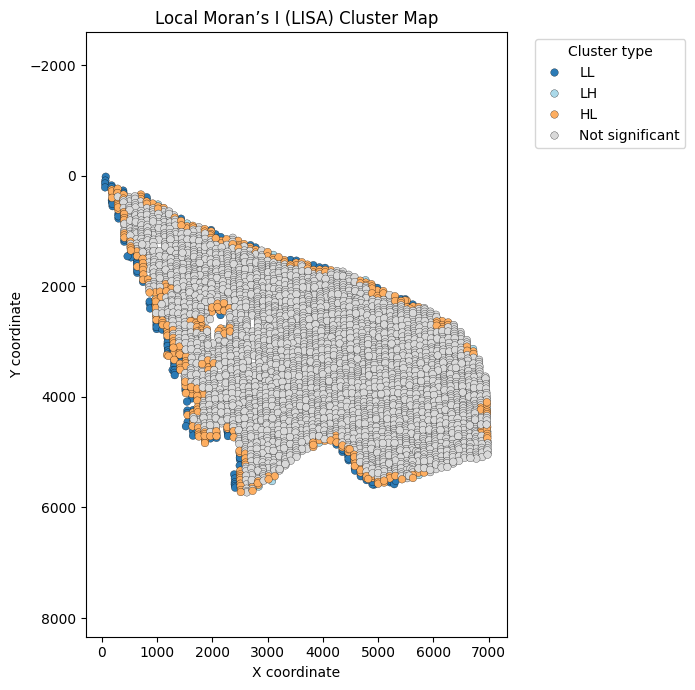

In [51]:
import seaborn as sns

palette = {
    'HH (Hotspot)': '#d7191c',   # red
    'LL': '#2c7bb6',             # blue
    'HL': '#fdae61',             # orange
    'LH': '#abd9e9',             # light blue
    'Not significant': '#d9d9d9'
}

plt.figure(figsize=(7, 7))
# Invert Y-axis to match image/matrix layout (0,0 at top-left)
plt.gca().invert_yaxis()

sns.scatterplot(
    data=df,
    x='xc', y='yc',
    hue='LISA_cluster',
    palette=palette,
    s=30,
    edgecolor='k',
    linewidth=0.2
)

plt.title("Local Moran’s I (LISA) Cluster Map")
plt.xlabel("X coordinate")
plt.ylabel("Y coordinate")
plt.axis('equal')
plt.legend(title="Cluster type", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

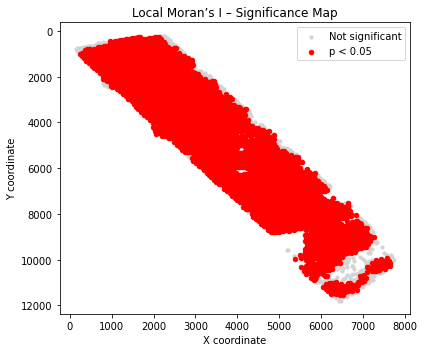

In [59]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))
# Invert Y-axis to match image/matrix layout (0,0 at top-left)
plt.gca().invert_yaxis()

sig = df['Local_p'] > 0.05

plt.scatter(
    df.loc[~sig, 'xc'],
    df.loc[~sig, 'yc'],
    c='lightgray',
    s=10,
    label='Not significant'
)

plt.scatter(
    df.loc[sig, 'xc'],
    df.loc[sig, 'yc'],
    c='red',
    s=20,
    label='p < 0.05'
)

plt.xlabel("X coordinate")
plt.ylabel("Y coordinate")
plt.title("Local Moran’s I – Significance Map")
plt.legend()
plt.tight_layout()
plt.show()

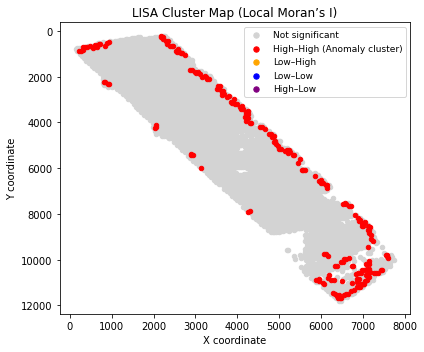

In [60]:
# Define colors for LISA cluster types
cluster_colors = {
    0: 'lightgray',  # not significant
    1: 'red',        # High-High (anomaly hotspot)
    2: 'orange',     # Low-High
    3: 'blue',       # Low-Low
    4: 'purple'      # High-Low
}

df['LISA_label'] = np.where(df['Local_p'] < 0.05, df['Target'], 0)

plt.figure(figsize=(6,5))
# Invert Y-axis to match image/matrix layout (0,0 at top-left)
plt.gca().invert_yaxis()

for c, color in cluster_colors.items():
    subset = df[df['LISA_label'] == c]
    plt.scatter(
        subset['xc'],
        subset['yc'],
        c=color,
        s=20,
        label={
            0: 'Not significant',
            1: 'High–High (Anomaly cluster)',
            2: 'Low–High',
            3: 'Low–Low',
            4: 'High–Low'
        }[c]
    )

plt.xlabel("X coordinate")
plt.ylabel("Y coordinate")
plt.title("LISA Cluster Map (Local Moran’s I)")
plt.legend(markerscale=1.2, fontsize=9)
plt.tight_layout()
plt.show()

In [64]:
#!pip install pointpats

#### Ripley

In [57]:
from pointpats import k
# anomaly points
points = df.loc[df.Target == 0, ['xc', 'yc']].values
r = np.linspace(0, 40, 100)
#print(r)
k_sup, k_estimate = k(points, r)

#_, K = ripley_k(points, width, height, 40, 100)
#print(np.array(k_estimate-K).sum())
#print(K-k_estimate)
#print(K)

In [34]:
def csr_simulation(n, area_bounds):
    x_min, x_max, y_min, y_max = area_bounds
    x = np.random.uniform(x_min, x_max, n)
    y = np.random.uniform(y_min, y_max, n)
    return np.column_stack((x, y))

In [24]:
n_sim = 99
K_sim = np.zeros((n_sim, len(r)))
L_sim = np.zeros((n_sim, len(r)))
x_min, x_max = df.xc.min(), df.xc.max()
y_min, y_max = df.yc.min(), df.yc.max()

for i in range(n_sim):
    # CSR simulation
    #random_list = np.array([random.randint(min_value, max_value) for _ in range(array_size)]).reshape(-1, 1)
    #random_list2 = np.array([random.randint(min_value, max_value) for _ in range(array_size)]).reshape(-1, 1)
    #sim_pp = np.concatenate((random_list, random_list2), 1)
    sim_pp = csr_simulation(len(points), (x_min, x_max, y_min, y_max))
    #print(sim_pp.shape)
    #print(k(sim_pp, r).shape)
    #print(len(k(sim_pp, r)))
    _,k_test = k(sim_pp, r)
    K_sim[i] = k_test
    L_sim[i] = np.sqrt(k_test/np.pi) - r

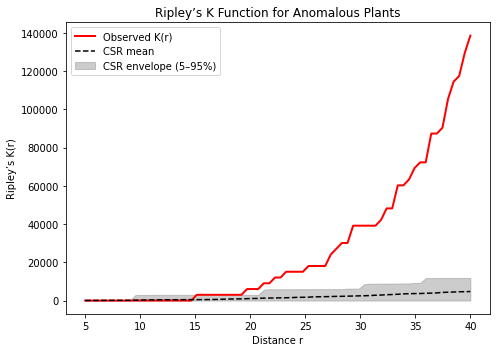

In [120]:
plt.figure(figsize=(7, 5))

plt.plot(r, k_estimate, color='red', lw=2, label='Observed K(r)')
plt.plot(r, K_sim.mean(axis=0), '--', color='black', label='CSR mean')

plt.fill_between(
    r,
    np.percentile(K_sim, 5, axis=0),
    np.percentile(K_sim, 95, axis=0),
    color='gray',
    alpha=0.4,
    label='CSR envelope (5–95%)'
)
#plt.plot(r, np.pi * r**2, '--', label='CSR expectation')

plt.xlabel("Distance r")
plt.ylabel("Ripley’s K(r)")
plt.title("Ripley’s K Function for Anomalous Plants")
plt.legend()
plt.tight_layout()
plt.show()

In [47]:
points_ano = coords[labels==0]
len(points_ano)

67

In [35]:
import numpy as np
from scipy.spatial import KDTree

def ripley_k(points, width, height, r_max=500, n_steps=50):
    
    points = np.asarray(points)
    n = len(points)
    
    area = width * height
    density = n / area
    
    radii = np.linspace(0, r_max, n_steps)
    
    tree = KDTree(points)
    
    K = np.zeros(len(radii))
    
    for i, r in enumerate(radii):
        
        neighbors = tree.query_ball_tree(tree, r)
        
        count = sum(len(x) - 1 for x in neighbors)
        
        K[i] = count / (n * density)
    
    return radii, K


def ripley_l(K):
    return np.sqrt(K / np.pi)


def ripley_h(r, L):
    return L - r


def ripley_analysis(points, width, height,
                    r_max=500,
                    n_steps=50,
                    n_sim=100):

    #r, K = ripley_k(points, width, height, r_max, n_steps)
    r = np.linspace(0, r_max, n_steps)
    r, K = k(points, r)

    L = ripley_l(K)
    H = ripley_h(r, L)

    sims = []

    for _ in range(n_sim):

        rand_points = np.column_stack([
            np.random.uniform(0, width, len(points)),
            np.random.uniform(0, height, len(points))
        ])

        _, K_sim = ripley_k(rand_points, width, height, r_max, n_steps)
        L_sim = ripley_l(K_sim)
        H_sim = ripley_h(r, L_sim)

        sims.append(H_sim)

    sims = np.array(sims)

    lower = np.percentile(sims, 2.5, axis=0)
    upper = np.percentile(sims, 97.5, axis=0)

    auc_h = np.trapz(H, r)

    return {
        "r": r,
        "K": K,
        "L": L,
        "H": H,
        "lower_env": lower,
        "upper_env": upper,
        "AUC_H": auc_h
    }

In [36]:
import matplotlib.pyplot as plt

def plot_ripley(result):

    r = result["r"]
    H = result["H"]

    plt.figure(figsize=(6,5))

    plt.plot(r, H, color = "red", lw=2, label="Observed H(r)")
    plt.fill_between(r,
                     result["lower_env"],
                     result["upper_env"],
                     alpha=0.3,
                     label="95% CSR envelope")

    plt.axhline(0, linestyle="--")

    plt.xlabel("Radius (pixels)")
    plt.ylabel("H(r) = L(r) - r")
    plt.legend()

    plt.title("Ripley Spatial Clustering")
    plt.savefig(folder_save_results+zone_name+"_Ripley", dpi=300)
    
    plt.show()

In [88]:
img_rgb = cv2.imread(folder_maps + zone_name + "_target.png")
img_rgb.shape, zone_name

((11942, 7897, 3), 'Zone102_part1')

In [89]:
points_ano = coords[labels==0]

C:\Users\diego\AppData\Local\Temp\ipykernel_15116\1049581204.py:69: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  auc_h = np.trapz(H, r)


AUC_H: 601467.4685862005


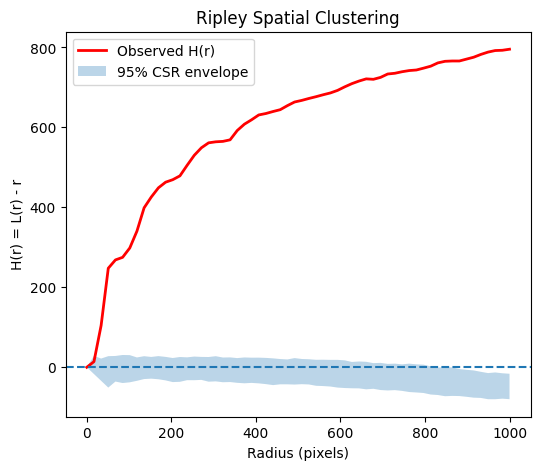

In [90]:
result = ripley_analysis(
            points_ano,
            width=img_rgb.shape[0],
            height=img_rgb.shape[1],
            r_max=1000,
            n_steps=60,
            n_sim=200)

print("AUC_H:", result["AUC_H"])

plot_ripley(result)

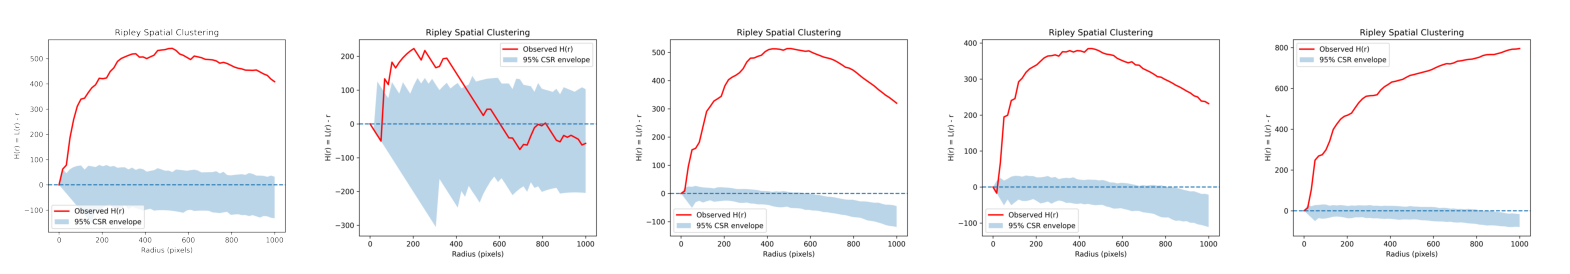

In [97]:
import matplotlib.image as mpimg

zone_name1 = "Zone1"
zone_name2 = "Zone3"
zone_name3 = "Zone109"
zone_name4 = "Zone108_octubre"
zone_name5 = "Zone102_part1"

paths = [
    folder_save_results+zone_name1+"_Ripley.png",
    folder_save_results+zone_name2+"_Ripley.png",
    folder_save_results+zone_name3+"_Ripley.png",
    folder_save_results+zone_name4+"_Ripley.png",
    folder_save_results+zone_name5+"_Ripley.png",
]

fig, axes = plt.subplots(1, 5, figsize=(20, 4))

for ax, path in zip(axes, paths):
    img = mpimg.imread(path)
    ax.imshow(img)
    ax.axis('off')

plt.subplots_adjust(wspace=0.02, hspace=0.0)
plt.savefig(folder_save_results+"Ripley_graphs", dpi=300)
plt.show()

In [163]:
#!pip install libpysal
#!pip install esda

In [17]:
#!pip install diptest


In [31]:
zone_names = ['Zone1', 'Zone3', 'Zone109', 'Zone108', 'Zone108_octubre', 'Zone102_part1']
def sci(x):
    if abs(x) >= 1e-3:
        return f"{x:.3f}"
    else:
        base, exp = f"{x:.2e}".split('e')
        return f"{base} \\tiny{{$\\times 10^{{{int(exp)}}}$}}"
    
for i, zone_name in enumerate(zone_names):
    
    file_name = file_name = folder_save_results+zone_name+'_statistics_all_features.csv'
    df = pd.read_csv(file_name, index_col=0)

    metrics = df['Value'].values

    formatted = [sci(x) for x in metrics[:8]]

    print(zone_name+" & " + " & ".join(formatted) + " \\\\ \\hline")

Zone1 & 0.325 & 9.99 \tiny{$\times 10^{-4}$} & 9.99 \tiny{$\times 10^{-4}$} & 0.001 & 0.079 & 0.250 & 7.202 & 6.431 \\ \hline
Zone3 & 0.176 & 9.99 \tiny{$\times 10^{-4}$} & 9.99 \tiny{$\times 10^{-4}$} & 0.001 & 0.041 & 0.180 & 8.744 & 4.537 \\ \hline
Zone109 & 0.042 & 0.063 & 0.042 & 0.001 & 0.443 & 0.289 & 5.378 & 2.407 \\ \hline
Zone108 & 0.299 & 0.150 & 0.095 & 0.001 & 0.330 & 0.296 & 0.062 & 1.999 \\ \hline
Zone108_octubre & 0.307 & 0.123 & 1.000 & 0.001 & 0.346 & 0.235 & 0.046 & 1.999 \\ \hline
Zone102_part1 & 9.76 \tiny{$\times 10^{-15}$} & 9.99 \tiny{$\times 10^{-4}$} & 9.99 \tiny{$\times 10^{-4}$} & 0.001 & 0.347 & 0.304 & 131.193 & 2.734 \\ \hline


In [13]:
df

,Metric,Value
0,Energy p-value,9.759865e-15
1,Energy Permutation p-value,9.990010e-04
2,PERMANOVA p-value,9.990010e-04
3,Mooran's I p_value,1.000000e-03
4,Mooran's I,3.469737e-01
5,Silhouette,3.042937e-01
6,Calinski–Harabasz,1.311929e+02
7,Davies–Bouldin,2.733903e+00


In [64]:
zone_names = ['Zone1', 'Zone3', 'Zone109', 'Zone108_octubre', 'Zone102_part1']
    
for i, zone_name in enumerate(zone_names):
    
    file_name = file_name = folder_save_results+zone_name+'_statistics_features.csv'
    df1 = pd.read_csv(file_name, index_col=0)



In [91]:
#zone_name="Zone108_octubre"
zone_name="Zone108"
file_name = file_name = folder_save_results+zone_name+'_statistics_features.csv'
df1 = pd.read_csv(file_name, index_col=0)
df1 = df1.rename(columns={"Cliff's Delta": "Cliffs Delta"})

#zone_name="Zone102_part1"
zone_name="Zone108_octubre"
file_name = file_name = folder_save_results+zone_name+'_statistics_features.csv'
df2 = pd.read_csv(file_name, index_col=0)
df2 = df2.rename(columns={"Cliff's Delta": "Cliffs Delta"})

In [92]:
import pandas as pd

def format_sci_latex(x, threshold=1e-3, color_if_gt='purple'):
    if pd.isna(x):
        return ""

    # Base formatting
    if abs(x) >= threshold:
        val_str = f"{x:.3f}"
    else:
        base, exp = f"{x:.2e}".split('e')
        val_str = f"{float(base):.2f} \\tiny{{$\\times 10^{{{int(exp)}}}$}}"

    # Apply color if needed
    if (color_if_gt is not None) and (x > 0.05):
        return f"\\textcolor{{purple}}{{{val_str}}}"
    
    return val_str

def df_to_latex_table(df):
    lines = []
    
    header = (
        "\\begin{table}[h]\n"
        "\\centering\n\\small\n"
        "\\begin{tabular}{lccc}\n\\hline\n"
        "Feature & KS p-value & Mann--Whitney p-value & Cliff's $\\Delta$ \\\\\n\\hline"
    )
    
    lines.append(header)

    for _, row in df.iterrows():
        feature = row["Feature"]
        ks = format_sci_latex(row["KS p-value"])
        mw = format_sci_latex(row["Mann–Whitney p-value"])
        delta = f"{row['Cliffs Delta']:.3f}"

        lines.append(f"{feature} & {ks} & {mw} & {delta} \\\\")
    

    footer = "\\hline\n\\end{tabular}\n\\caption{Statistical comparison.}\n\\end{table}"
    lines.append(footer)

    return "\n".join(lines)
def df_multi_to_latex(dfs_dict):
    """
    dfs_dict = {
        "Field1": df1,
        "Field2": df2,
        ...
    }
    """

    fields = list(dfs_dict.keys())
    n = len(fields)

    header = "\\begin{table*}[h]\n\\centering\n\\small\n"
    header += "\\begin{tabular}{l" + "ccc|"*(n-1) + "ccc}\n\\hline\n"

    # Top header
    header += " & " + " & ".join([f"\\multicolumn{{3}}{{c}}{{{f}}}" for f in fields]) + " \\\\\n"

    # Sub header
    subcols = " & ".join(["KS p-value & MW p-value & $\\Delta$"] * n)
    header += f"Feature & {subcols} \\\\\n\\hline"

    lines = [header]

    # assume same feature order
    base_df = list(dfs_dict.values())[0]

    for i in range(len(base_df)):
        row_line = [base_df.iloc[i]["Feature"]]

        for f in fields:
            df = dfs_dict[f]

            ks = format_sci_latex(df.iloc[i]["KS p-value"])
            mw = format_sci_latex(df.iloc[i]["Mann–Whitney p-value"])
            delta = f"{df.iloc[i]['Cliffs Delta']:.3f}"

            row_line.extend([ks, mw, delta])

        lines.append(" & ".join(row_line) + " \\\\")

    footer = "\\hline\n\\end{tabular}\n\\caption{Comparison across fields.}\n\\end{table*}"
    lines.append(footer)

    return "\n".join(lines)

In [93]:
dfs = {
    "Zone1": df1,
    "Zone2": df2
}

latex_code = df_multi_to_latex(dfs)
print(latex_code)

\begin{table*}[h]
\centering
\small
\begin{tabular}{lccc|ccc}
\hline
 & \multicolumn{3}{c}{Zone1} & \multicolumn{3}{c}{Zone2} \\
Feature & KS p-value & MW p-value & $\Delta$ & KS p-value & MW p-value & $\Delta$ \\
\hline
A & 1.47 \tiny{$\times 10^{-5}$} & 1.52 \tiny{$\times 10^{-6}$} & -0.233 & \textcolor{purple}{0.463} & \textcolor{purple}{0.573} & 0.027 \\
P & 1.74 \tiny{$\times 10^{-6}$} & 7.50 \tiny{$\times 10^{-7}$} & -0.239 & \textcolor{purple}{0.095} & \textcolor{purple}{0.123} & 0.074 \\
Compactness & 0.036 & 0.003 & -0.145 & 2.47 \tiny{$\times 10^{-5}$} & 6.69 \tiny{$\times 10^{-6}$} & 0.217 \\
Circularity & 0.034 & 0.002 & 0.147 & 2.59 \tiny{$\times 10^{-5}$} & 7.26 \tiny{$\times 10^{-6}$} & -0.216 \\
Solidity & 0.010 & 0.001 & 0.158 & 2.61 \tiny{$\times 10^{-4}$} & 4.18 \tiny{$\times 10^{-4}$} & -0.170 \\
Contrast & \textcolor{purple}{0.205} & \textcolor{purple}{0.368} & -0.044 & 1.14 \tiny{$\times 10^{-9}$} & 5.26 \tiny{$\times 10^{-11}$} & 0.316 \\
Dissimilarity & \textcol

## Plots

In [16]:
df_2 = df[['A', 'P', 'Compactness', 'Circularity', 'Solidity', 
                  'Contrast', 'Dissimilarity', 'Homogeneity', 'ASM', 'Energy', 
                  'ARVI', 'NDCI', 'TSAVI2', 'NDVI', 'GNDVI']]

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt
import math

def plot_feature_distributions(df, cols=None, ncols=5):

    if cols is None:
        cols = df.columns

    n = len(cols)
    nrows = math.ceil(n / ncols)

    sns.set_style("whitegrid")

    fig, axes = plt.subplots(nrows, ncols, figsize=(4*ncols, 3*nrows))
    axes = axes.flatten()

    for i, col in enumerate(cols):

        # Filter data to exclude top and bottom 1%
        lower = df[col].quantile(0.001)
        upper = df[col].quantile(0.999)
        df_filtered = df[(df[col] >= lower) & (df[col] <= upper)]

        sns.histplot(
            df_filtered[col],
            bins=40,
            kde=True,
            ax=axes[i]
        )

        axes[i].set_title(col, fontsize=11)
        axes[i].set_xlabel("")
        axes[i].set_ylabel("")

    # remove unused axes
    for j in range(i+1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.savefig(folder_save_results+zone_name+"_distributions", dpi=300)
    plt.show()

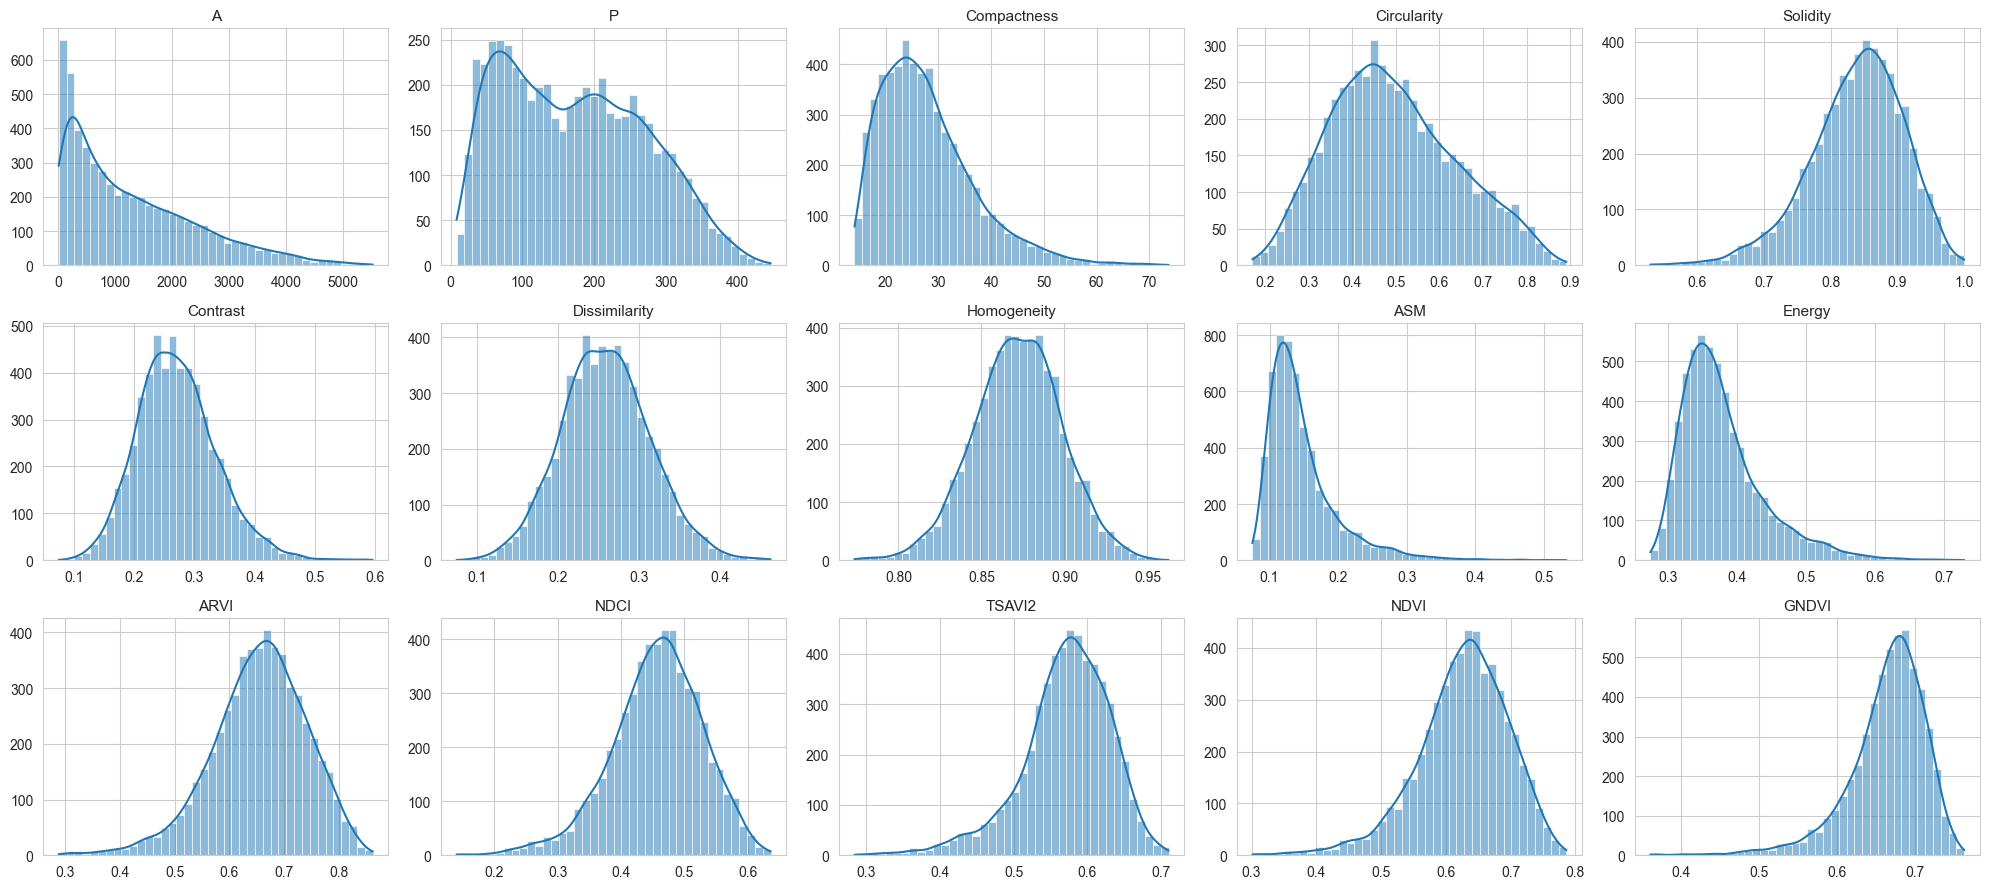

In [18]:
plot_feature_distributions(df_2)

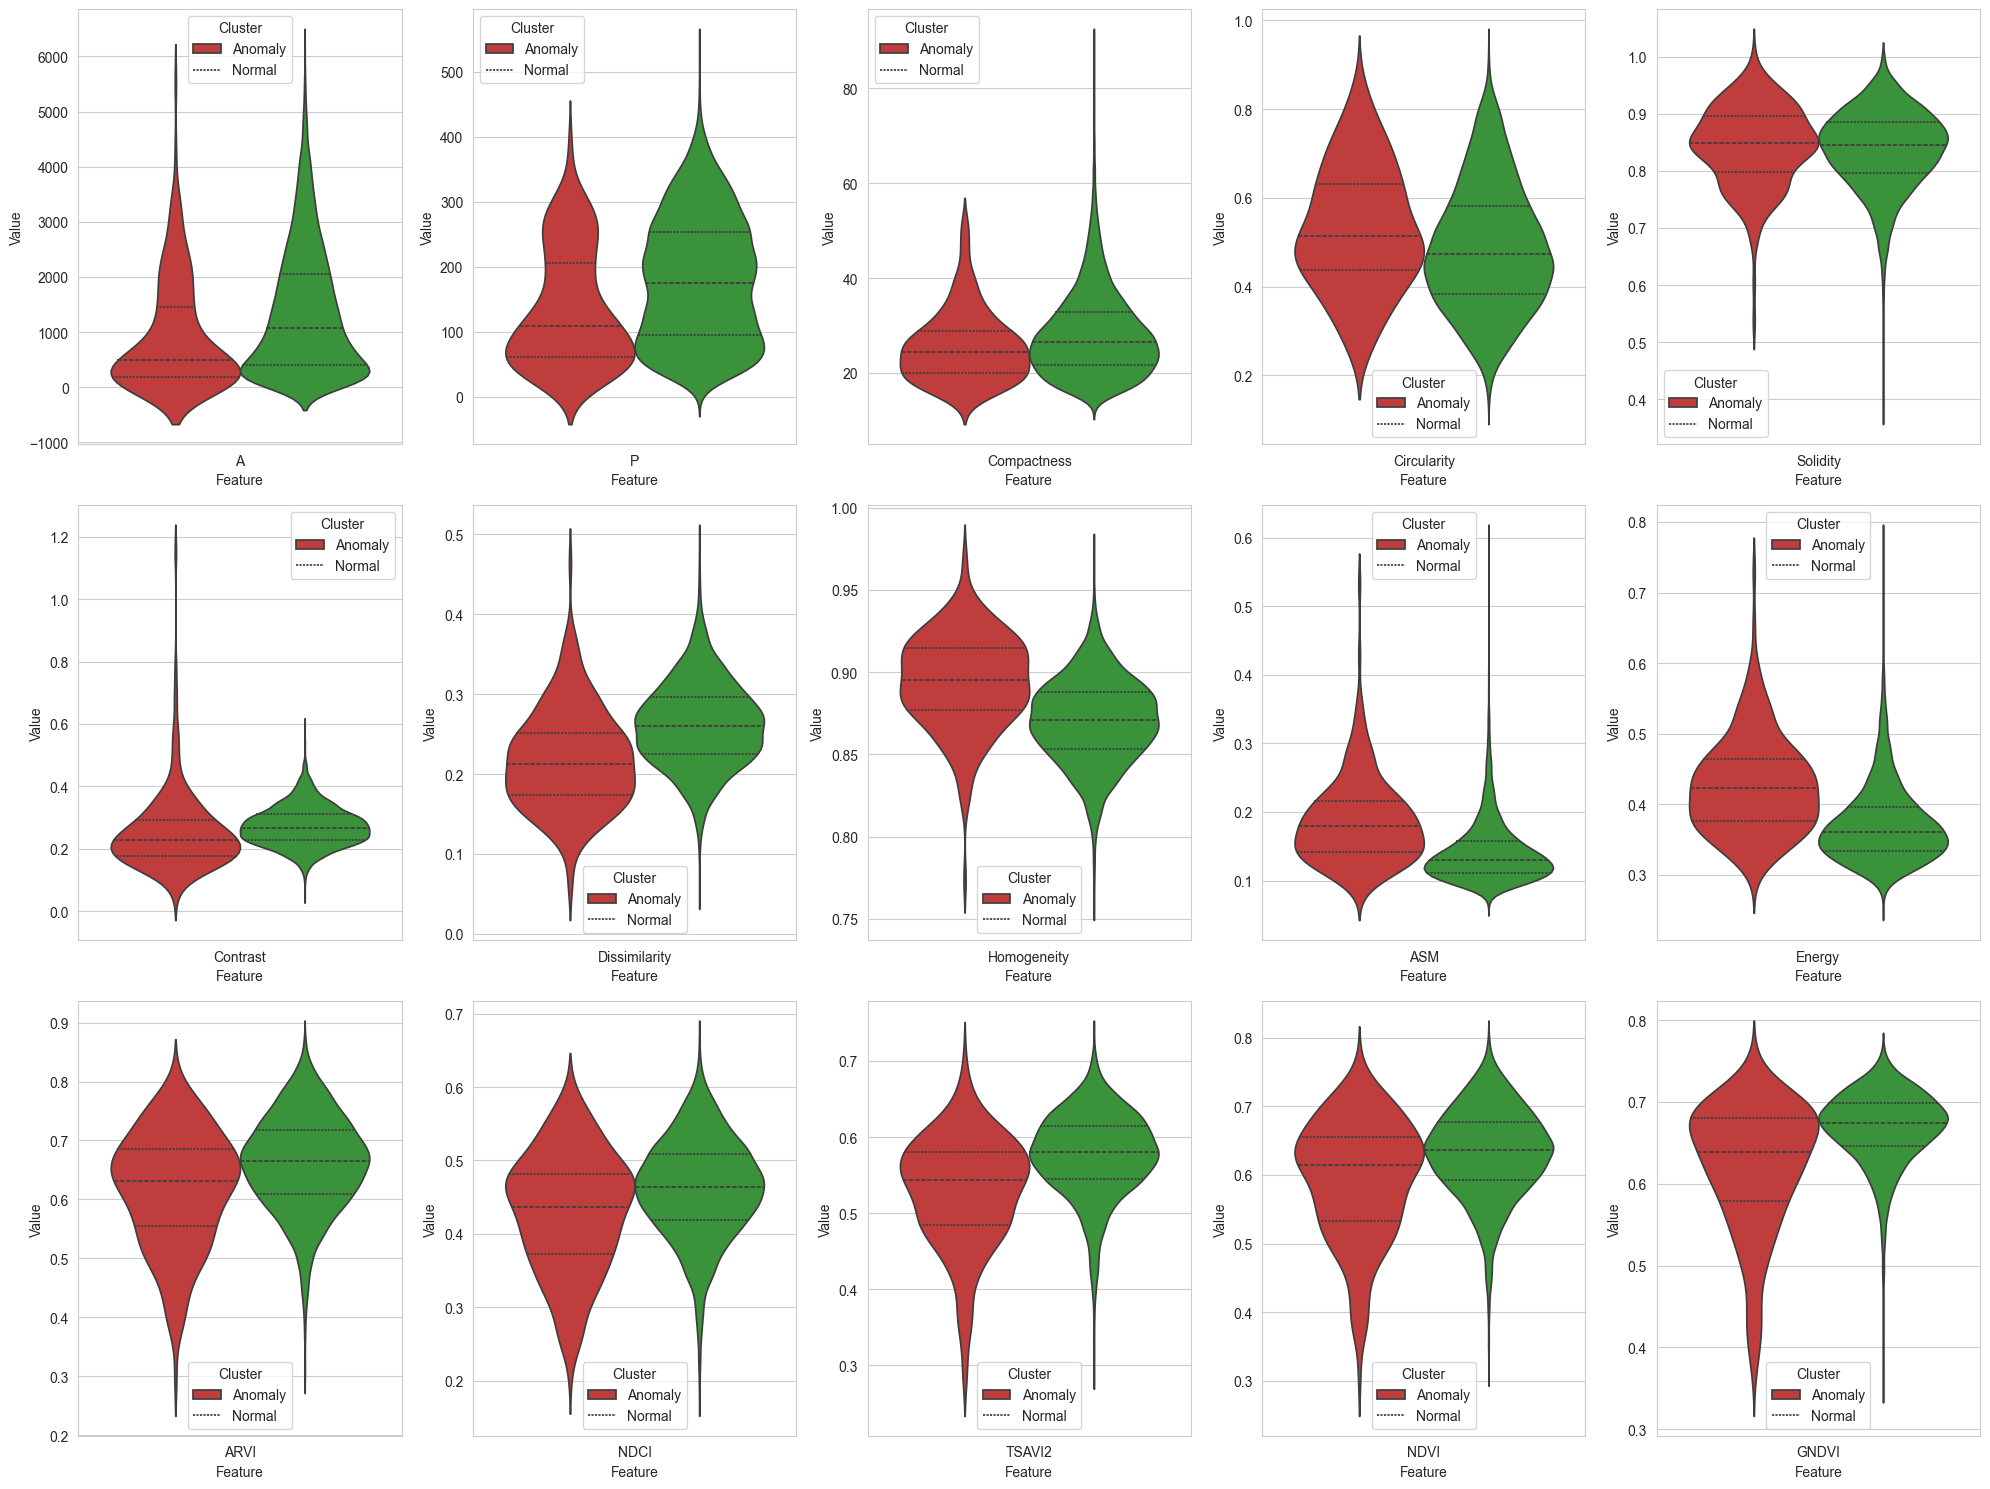

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

#selected_feats = feature_cols#["A", "Dissimilarity", "Energy", "NDVI", "EVI"]
selected_feats = [['A', 'P', 'Compactness', 'Circularity', 'Solidity'], 
                  ['Contrast', 'Dissimilarity', 'Homogeneity', 'ASM', 'Energy'], 
                  ['ARVI', 'NDCI', 'TSAVI2', 'NDVI', 'GNDVI']]

plt.figure(figsize=(20, 15))

for i in range(len(selected_feats)):
    for j in range(len(selected_feats[0])):
        #print(5*i+j+1, i, j)
        plt.subplot(len(selected_feats),len(selected_feats[0]), 5*i+j+1)
        df_plot = df.melt(
            id_vars="Target",
            value_vars=selected_feats[i][j],
            var_name="Feature",
            value_name="Value"
        )
        
        sns.violinplot(
            data=df_plot,
            x="Feature",
            y="Value",
            hue="Target",          # <-- FIX HERE
            #split=True,
            inner="quartile",
            palette={0: "tab:red", 1: "tab:green"}
        )
        
        plt.legend(title="Cluster", labels=["Anomaly", "Normal"])
        #plt.title("Distributional shifts for representative plant features")
        plt.tight_layout()
plt.savefig("plots", dpi=250)
plt.show()

In [292]:
len(selected_feats),len(selected_feats[0])

(3, 5)

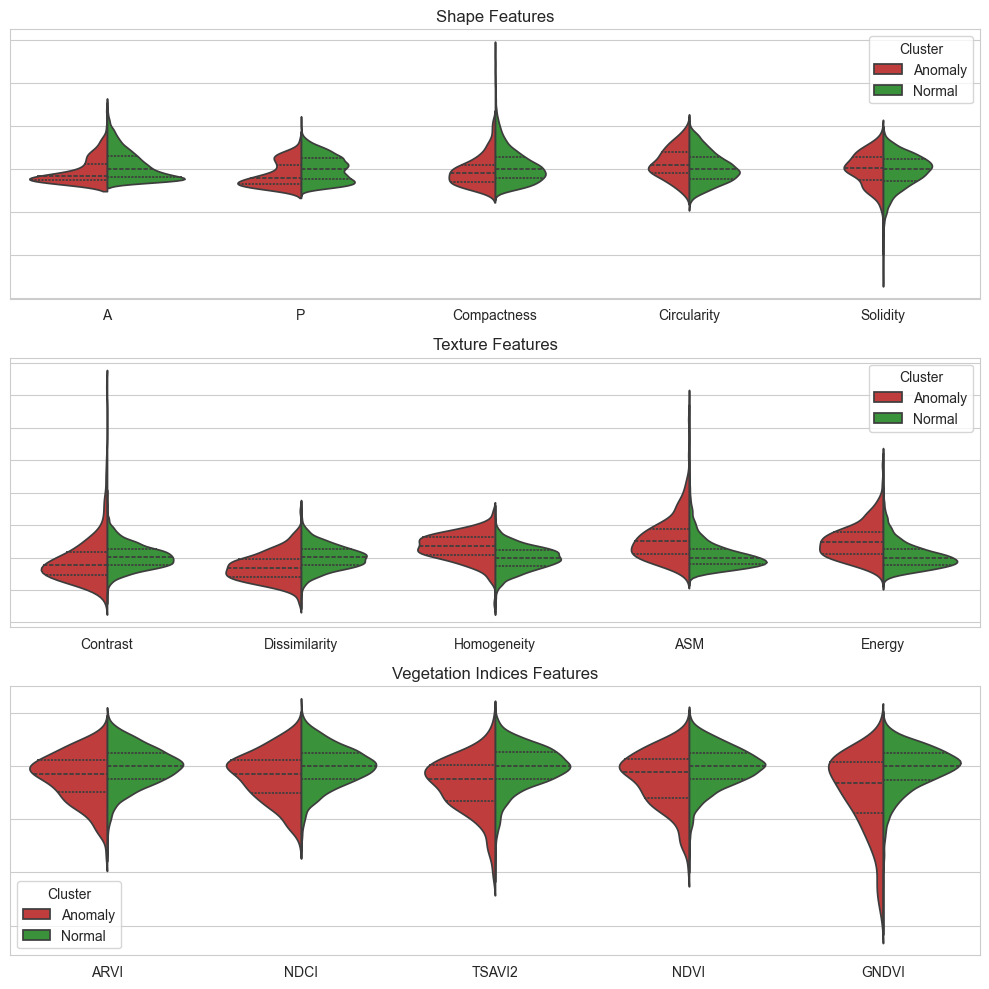

In [55]:
import seaborn as sns
import matplotlib.pyplot as plt

#selected_feats = feature_cols#["A", "Dissimilarity", "Energy", "NDVI", "EVI"]
selected_feats = ['A', 'P', 'Compactness', 'Circularity', 'Shape_index', 
                  'Contrast', 'Dissimilarity', 'Homogeneity', 'ASM', 'Energy', 
                  'NDVI', 'PVI2', 'SAVI', 'TSAVI2', 'NDGI', 'ARVI', 'GNDVI', 'OSAVI']

selected_feats = [['A', 'P', 'Compactness', 'Circularity', 'Solidity'], 
                  ['Contrast', 'Dissimilarity', 'Homogeneity', 'ASM', 'Energy'], 
                  ['ARVI', 'NDCI', 'TSAVI2', 'NDVI', 'GNDVI']]

titles = ["Shape Features", "Texture Features", "Vegetation Indices Features"]
plt.figure(figsize=(10, 10))

for i in range(len(selected_feats)):
    plt.subplot(len(selected_feats),1, i+1)
    df_plot = df_scaled.melt(
        id_vars="Target",
        value_vars=selected_feats[i],
        var_name="Feature",
        value_name="Value"
    )
    df_plot['Target'] = df_plot['Target'].replace({0:'Anomaly', 1:'Normal'})
    
    ax = sns.violinplot(
        data=df_plot,
        x="Feature",
        y="Value",
        hue="Target",          # <-- FIX HERE
        split=True,
        inner="quartile",
        palette={"Anomaly": "tab:red", "Normal": "tab:green"}
    )
    
    #plt.legend(title="Cluster", labels=["Anomaly", "Normal"])
    plt.legend(title="Cluster")
    plt.title(titles[i])

    ax.set_xlabel("") 
    #ax.set_ylabel("") 
    #ax.get_yaxis().set_visible(False)

    # Remove yticklabels
    ax.set_yticklabels([])
    ax.set_ylabel('') # Removes "total_bill" label

    plt.tight_layout()
plt.savefig("anomaly_distribution", dpi=300)
plt.show()